# Seleccion de Lags: AMI+FNN, Grey Relational y ACF/PACF

Este notebook explica el modulo `src/features/lag_selection`, que responde una pregunta concreta del pipeline: **cuantos lags (y ventanas rolling) usar, y cuales**.

En vez de elegir los lags a ojo (antes `[1, 2, 3, 5, 10]`), se ofrecen tres estrategias guiadas por datos y un validador que las compara con walk-forward cronologico sobre los datos reales `data/historico_consumo.parquet`.

## Diseno (Strategy + Validator)

| Pieza | Rol |
| :--- | :--- |
| `LagSpec` | Contrato comun de salida: `lags`, `windows`, `method`, `metadata`. |
| `LagSelectionStrategy` (ABC) | Interfaz: `select(serie)` + `aggregate(specs)` + `fit_panel(df)`. |
| `AmiFnnSelector` | Embedding de Takens: retardo tau por AMI, dimension m por FNN. |
| `GreyRelationalSelector` | Grado relacional gris (Deng); robusto en series cortas. |
| `AcfPacfSelector` | Box-Jenkins: lags con PACF significativa. |
| `LagFeatureValidator` | Corre cada estrategia y las rankea por MAE/WAPE/peak recall. |

## 1. Carga de datos reales

In [1]:
import sys
import os
import warnings
import datetime

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
import plotly.graph_objects as go

from src.utils import transform_data
from src.features.lag_selection import (
    AmiFnnSelector,
    GreyRelationalSelector,
    AcfPacfSelector,
    LagFeatureValidator,
    build_lag_features,
)

data_name = "historico_consumo.parquet"
data_path = (
    os.path.join("data", data_name)
    if os.path.exists(os.path.join("data", data_name))
    else os.path.join("..", "data", data_name)
)

df_raw = pl.read_parquet(data_path)
df = transform_data(df_raw)

print("Filas:", f"{df.height:_}")
print("Series (planta, sku):", df.select(["planta", "sku"]).unique().height)
print("Rango de fechas:", df["fecha"].min(), "->", df["fecha"].max())
df.select(["planta", "sku", "fecha", "consumo_real", "forecast_mensual", "target_consumo_real", "target_is_peak"]).head(5)

Filas: 423_906
Series (planta, sku): 952
Rango de fechas: 2022-09-28 -> 2026-05-27


planta,sku,fecha,consumo_real,forecast_mensual,target_consumo_real,target_is_peak
str,str,date,f64,f64,f64,i8
"""PCEL""","""HP2_01_105_2190""",2022-09-28,2.611,40.0,2.611,0
"""PCEL""","""HP2_01_105_2190""",2022-09-29,2.611,40.0,5.215,1
"""PCEL""","""HP2_01_105_2190""",2022-09-30,5.215,40.0,5.215,1
"""PCEL""","""HP2_01_105_2190""",2022-10-03,5.215,39.0,0.0,0
"""PCEL""","""HP2_01_105_2190""",2022-10-04,0.0,39.0,2.0,0


## 2. Una serie representativa

Para ilustrar cada metodo tomamos la serie con mas historia. Todas las estrategias estiman primero por serie (`select`) y luego agregan a un valor global rectangular (`aggregate`).

In [2]:
serie = df.group_by(["planta", "sku"]).len().sort("len", descending=True).head(1)
plant, sku = serie["planta"][0], serie["sku"][0]

columnas_filtrar = ["planta", "sku", "consumo_real", "fecha"]

serie = df.filter(
    pl.col("planta") == plant,
    pl.col("sku") == sku,
    pl.col("fecha") >= datetime.datetime(2025, 12, 31)
).select(columnas_filtrar).to_pandas()

fig = go.Figure(
    data = 
        go.Scatter(
            x=serie["fecha"],
            y=serie["consumo_real"],
            mode="lines+markers",

line=dict(color="firebrick", width=2)
        )
)

fig.update_layout(
    title= f"Consumo real diario (TO) {plant} - {sku} ",
    margin = dict(l=20, r=20, t=50, b=20),
    autosize = True
)
fig.show()

## 3. AmiFnnSelector (Takens)

**Idea:** reconstruir la dinamica con un time-delay embedding `v(t) = [s(t-1), s(t-1-tau), ...]`.

* **tau (AMI):** primer minimo de la Informacion Mutua Promedio entre la serie y su copia retrasada. Es la separacion donde cada coordenada aporta info nueva sin desconectarse.
* **m (FNN):** False Nearest Neighbors. Sube m hasta que los vecinos falsos (cercanos solo por falta de dimensiones) desaparecen.

Los lags resultantes son uniformes: `1, 1+tau, 1+2tau, ...`

In [3]:
from email import feedparser
from src.features.build_features import (
    _average_mutual_information,
    estimate_delay_ami,
    estimate_dimension_fnn,
)
# 1. Extraer la serie temporal unidimensional como un array de NumPy
s = serie["consumo_real"].to_numpy()

# 2. Calcular la curva AMI usando la serie unidimensional
max_tau = 30
ami_curve = [_average_mutual_information(s[:-k], s[k:]) for k in range(1, max_tau + 1)]

# 3. Estimar tau y m usando la serie unidimensional 's'
tau = estimate_delay_ami(s)
m = estimate_dimension_fnn(s, tau)

print(f"tau elegido = {tau}   |   m elegido = {m}")

# 4. Graficar los resultados
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(1, max_tau + 1)), y=ami_curve, mode="lines+markers", name="AMI"))
fig.add_vline(x=tau, line=dict(color="#d62728", dash="dash"), annotation_text=f"tau={tau}")
fig.update_layout(title="Average Mutual Information vs retardo", template="plotly_white",
                  xaxis_title="retardo tau", yaxis_title="AMI (nats)")
fig.show()


tau elegido = 3   |   m elegido = 10


In [9]:
import numpy as np
import polars as pl

# Identificar la serie con mas historia
grp = df.group_by(["planta", "sku"]).len().sort("len", descending=True).head(1)
plant, sku = grp["planta"][0], grp["sku"][0]

# Extraer su array 1-D de consumo (esto es lo que select() necesita)
s = (
    df.filter((pl.col("planta") == plant) & (pl.col("sku") == sku))
    .sort("fecha")["consumo_real"]
    .to_numpy()
    .astype(float)
)
print(f"Serie: {plant} / {sku}  ({s.size} dias)")

ami_sel = AmiFnnSelector()
spec_ami = ami_sel.select(s)
print("Spec por serie:", spec_ami.lags, "| metadata:", spec_ami.metadata)

# fit_panel: estima por las series mas largas y agrega a un global
spec_ami_global = ami_sel.fit_panel(df)
print("Spec GLOBAL (fit_panel):", spec_ami_global.lags, "| metadata:", spec_ami_global.metadata)


Serie: SBUR / KW2_01_125_2650  (917 dias)
Spec por serie: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28] | metadata: {'tau': 3, 'm': 10}
Spec GLOBAL (fit_panel): [1, 4, 7, 10, 13, 16, 19, 22, 25, 28] | metadata: {'tau': 3, 'm': 10}


## 4. GreyRelationalSelector (Grey Relational Analysis)

**Idea:** medir la similitud geometrica entre la serie y cada copia retrasada con el **grado relacional gris (GRG)** de Deng. No asume linealidad ni distribucion y funciona con **pocas muestras** (util en SKU con poca historia).

Para cada lag `j`: `GRG_j = media_k[ (Dmin + rho*Dmax) / (D_j(k) + rho*Dmax) ]`, con `rho = 0.5`. Se quedan los lags con GRG alto.

In [8]:
gra_sel = GreyRelationalSelector()
spec_gra = gra_sel.select(s)
grades = spec_gra.metadata["grades"]
lags_sorted = sorted(grades)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=lags_sorted, y=[grades[j] for j in lags_sorted],
    marker_color=["#2ca02c" if j in spec_gra.lags else "#c7c7c7" for j in lags_sorted],
    name="GRG",
))
fig.add_hline(y=gra_sel.grade_threshold, line=dict(color="#d62728", dash="dash"),
              annotation_text=f"umbral={gra_sel.grade_threshold}")
fig.update_layout(title="Grado relacional gris por lag (verde = seleccionado)", template="plotly_white",
                  xaxis_title="lag", yaxis_title="GRG")
fig.show()

print("Lags seleccionados (serie):", spec_gra.lags)
print("Spec GLOBAL (fit_panel):", gra_sel.fit_panel(df).lags)

Lags seleccionados (serie): [1, 3, 4, 6, 7, 11, 12, 18]
Spec GLOBAL (fit_panel): [1, 2, 3, 4, 5, 6, 7, 9]


## 5. AcfPacfSelector (Box-Jenkins)

**Idea:** la **PACF** (autocorrelacion parcial) mide la relacion directa con el lag `j` quitando el efecto de los intermedios. Un lag es relevante si su PACF sale de la banda de confianza. Es la version lineal clasica de la pregunta "cuantos lags".

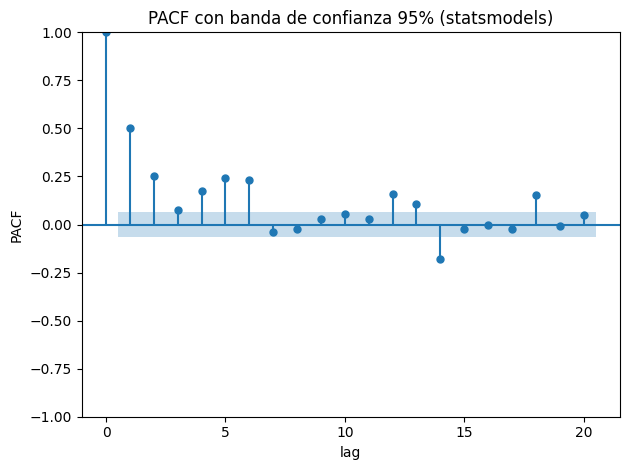

Lags significativos (serie): [1, 2, 3, 4, 5, 6, 12, 13, 14, 18]
Spec GLOBAL (fit_panel, soporte mayoritario): [1]


In [11]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

nlags = min(20, s.size // 2 - 1)

acf_sel = AcfPacfSelector()
spec_acf = acf_sel.select(s)

# Grafico PACF por defecto de statsmodels (la banda de confianza 95% viene incluida)
plot_pacf(s, lags=nlags)
plt.title("PACF con banda de confianza 95% (statsmodels)")
plt.xlabel("lag")
plt.ylabel("PACF")
plt.tight_layout()
plt.show()

print("Lags significativos (serie):", spec_acf.lags)
print("Spec GLOBAL (fit_panel, soporte mayoritario):", acf_sel.fit_panel(df).lags)


## 6. De un LagSpec a las features

`build_lag_features` materializa cualquier `LagSpec` en columnas `lag_{n}` y `rolling_{mean,std,max}_{w}` mas `daily_forecast` y calendario. Es el constructor de features de evaluacion que usa el validador.

In [12]:
df_feat, feature_cols = build_lag_features(df, spec_ami_global)
print("Numero de features:", len(feature_cols))
print(feature_cols)
df_feat.select(["planta", "sku", "fecha"] + feature_cols).drop_nulls().head(3)

Numero de features: 22
['lag_1', 'lag_4', 'lag_7', 'lag_10', 'lag_13', 'lag_16', 'lag_19', 'lag_22', 'lag_25', 'lag_28', 'rolling_mean_3', 'rolling_std_3', 'rolling_max_3', 'rolling_mean_5', 'rolling_std_5', 'rolling_max_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_max_10', 'daily_forecast', 'day_of_month', 'days_to_end_of_month']


planta,sku,fecha,lag_1,lag_4,lag_7,lag_10,lag_13,lag_16,lag_19,lag_22,lag_25,lag_28,rolling_mean_3,rolling_std_3,rolling_max_3,rolling_mean_5,rolling_std_5,rolling_max_5,rolling_mean_10,rolling_std_10,rolling_max_10,daily_forecast,day_of_month,days_to_end_of_month
str,str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i64
"""PCEL""","""HP2_01_105_2190""",2022-11-14,6.414,0.0,4.081,4.934,0.0,4.989,0.0,0.0,5.215,2.611,3.061333,2.967913,6.414,1.8368,2.686221,6.414,1.8199,2.440648,6.414,2.0,14,16
"""PCEL""","""HP2_01_105_2190""",2022-11-15,6.414,2.0,0.0,0.0,0.0,4.989,2.497,0.0,0.0,2.611,4.532667,3.258565,6.414,3.1196,3.0908,6.414,1.9679,2.683281,6.414,2.0,15,15
"""PCEL""","""HP2_01_105_2190""",2022-11-16,0.0,0.77,0.0,0.0,0.0,0.0,4.957,0.0,2.0,5.215,4.276,3.703125,6.414,3.1196,3.0908,6.414,1.9679,2.683281,6.414,2.0,16,14


## 7. LagFeatureValidator: comparacion walk-forward

El validador, para cada estrategia: ajusta el `LagSpec` global, construye features, y entrena un modelo nuevo en varios folds cronologicos (walk-forward, nunca aleatorio). Devuelve una tabla rankeada y guarda el `best_spec_`.

Reservamos el 20% final de la linea temporal como holdout y validamos solo dentro del train.

In [13]:
from lightgbm import LGBMRegressor as SkLGBM

cutoff = df["fecha"].quantile(0.8)
df_train = df.filter(pl.col("fecha") <= cutoff)
print("Train hasta:", cutoff, "| filas:", f"{df_train.height:_}")

validator = LagFeatureValidator(
    strategies=[AmiFnnSelector(), GreyRelationalSelector(), AcfPacfSelector()],
    model_factory=lambda: SkLGBM(n_estimators=200, learning_rate=0.05, max_depth=6, verbose=-1),
    n_splits=3,
    primary_metric="wape",
)
report = validator.run(df_train)
report

Train hasta: 2025-09-08 00:00:00 | filas: 339_200


method,n_lags,lags,windows,mae,wape,peak_recall,lift_vs_lag1_pct
str,i64,str,str,f64,f64,f64,f64
"""ami_fnn""",10,"""[1, 4, 7, 10, 13, 16, 19, 22, …","""[3, 5, 10]""",3.205134,0.783707,0.019089,15.29117
"""gra""",8,"""[1, 2, 3, 4, 5, 6, 9, 10]""","""[3, 5, 10]""",3.19568,0.785487,0.021708,15.221006
"""acf_pacf""",1,"""[1]""","""[3, 5, 10]""",3.196322,0.785645,0.021178,15.20412


In [14]:
pdf = report.to_pandas()

fig = go.Figure()
fig.add_trace(go.Bar(x=pdf["method"], y=pdf["wape"], name="WAPE", marker_color="#1f77b4"))
fig.update_layout(title="WAPE por estrategia (menor es mejor)", template="plotly_white",
                  xaxis_title="metodo", yaxis_title="WAPE")
fig.show()

print("Mejor metodo:", validator.best_spec_.method)
print("Lags ganadores:", validator.best_spec_.lags)
print("Ventanas:", validator.best_spec_.windows)

Mejor metodo: ami_fnn
Lags ganadores: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]
Ventanas: [3, 5, 10]


## 8. Conclusiones

* Las tres estrategias responden "cuantos lags" desde angulos distintos: dinamica no lineal (AMI+FNN), similitud de curvas con pocas muestras (GRA) y correlacion parcial lineal (ACF/PACF).
* El **walk-forward** es el juez final: por encima de cualquier criterio teorico, gana el que mejor predice fuera de muestra.
* `validator.best_spec_` es el `LagSpec` recomendado. En el diseno actual (aditivo) es **advisory**: `build_features` no lo consume todavia; se usa para decidir y documentar la eleccion de lags.
* Para series cortas (< 90 dias), GRA suele ser mas fiable que AMI/FNN; para series largas con estructura no lineal, AMI/FNN reconstruye mejor la dinamica.